# **Layer Thicknessess Analysis**

This notebook provides a comprehensive demonstration of how to perform layer thickness sensitivity analysis for multilayer thin-film coatings using the tmmax library. The analysis evaluates how variations in individual layer thicknesses influence the optical response—specifically reflectance and transmittance—of the entire stack, based on the transfer matrix method.

## **Materials and Layer Thickness**

We are considering the following material stack:

- **Air** as the incident medium.
- **Y₂O₃ (Yttrium oxide)** with a thickness of 630 nm.
- **TiO₂ (Titanium Dioxide)** with a thickness of 200 nm.
- **SiO₂ (Silicon Dioxide)** as the glass substrate.


---

## **Python Implementation**

In this section, we implement the TMM algorithm using the `tmmax` library, which is designed for high-performance multilayer simulations with vectorized operations using the `jax` library.

In [1]:
import jax.numpy as jnp
from tmmax.tmm import tmm

# Define your multilayer stack and simulation parameters

material_list = ["Air", "Y2O3", "TiO2", "Y2O3", "TiO2", "Y2O3", "TiO2", "SiO2"]
thickness_list = jnp.array([630e-9, 200e-9, 630e-9, 200e-9, 630e-9, 200e-9])  
wavelength_arr  = jnp.linspace(500e-9, 700e-9, 1000)
angle_of_incidences  = jnp.linspace(0, (70*jnp.pi/180), 1000)
polarization = 's'

result_s = tmm(material_list = material_list,
               thickness_list = thickness_list,
               wavelength_arr = wavelength_arr,
               angle_of_incidences = angle_of_incidences,
               polarization = polarization)

polarization = 'p'

result_p = tmm(material_list = material_list,
               thickness_list = thickness_list,
               wavelength_arr = wavelength_arr,
               angle_of_incidences = angle_of_incidences,
               polarization = polarization)

## **Visualization of Results**

We will now visualize the reflectance for both s-polarization and p-polarization as a function of wavelength and angle of incidence. The color map will represent the reflectance percentage.

### **Reflectance Results**

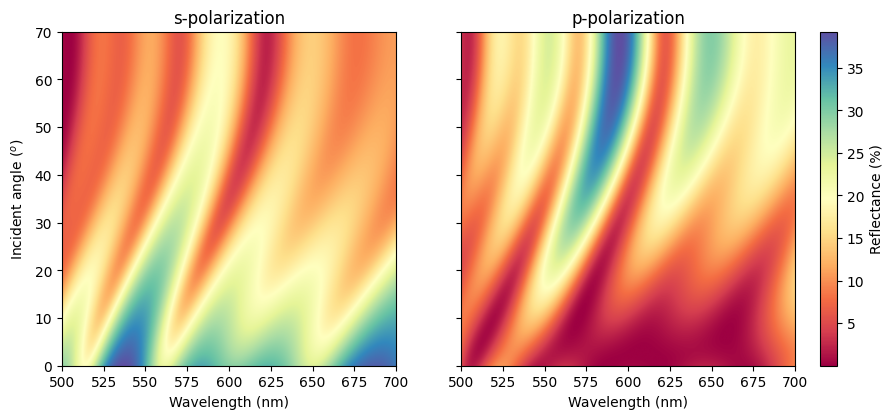

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[0]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[0]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Reflectance (%)')

plt.savefig("thickness_sensitivity_reflectance_s_p.png", dpi=600)
plt.show()

### **Transmittance Results**

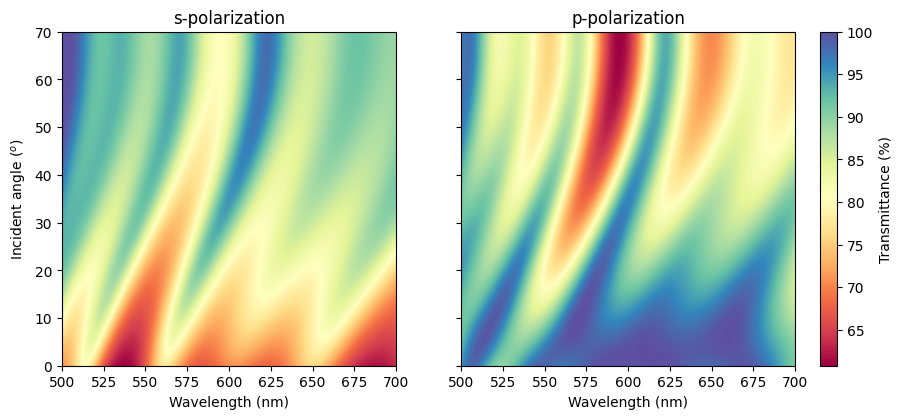

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[1]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[1]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Transmittance (%)')

plt.savefig("thickness_sensitivity_transmittance_s_p.png", dpi=600)
plt.show()

### **Layer Thicknessess Analysis**

In [4]:
from tmmax.analysis import thickness_sensitivity

thickness_deviation_list = jnp.array([1,2, 1, 2, 1, 2]) # Percentage 1 means 1 percent deviation

R_dev_spol, T_dev_spol = thickness_sensitivity(
    material_list=material_list,
    thickness_list=thickness_list,
    thickness_deviation_list=thickness_deviation_list,
    wavelength_arr=wavelength_arr,
    angle_of_incidences=angle_of_incidences,
    polarization='s',
    sensitivity_analysis_sample_num=20,
    seed=1903
)

### **Layer Thicknessess Results**

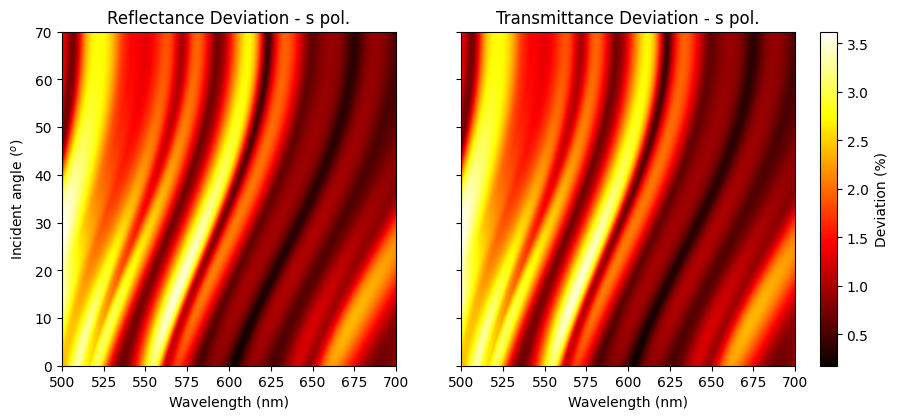

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(R_dev_spol*100, cmap='hot', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("Reflectance Deviation - s pol.")
    if i ==1:
        im = ax.imshow(T_dev_spol*100, cmap='hot', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("Transmittance Deviation - s pol.")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Deviation (%)')

plt.savefig("thickness_sensitivity_s_pol.png", dpi=600)
plt.show()

In [6]:
R_dev_ppol, T_dev_ppol = thickness_sensitivity(
        material_list=material_list,
        thickness_list=thickness_list,
        thickness_deviation_list=thickness_deviation_list,
        wavelength_arr=wavelength_arr,
        angle_of_incidences=angle_of_incidences,
        polarization='p',
        sensitivity_analysis_sample_num=20,
        seed=1903
)

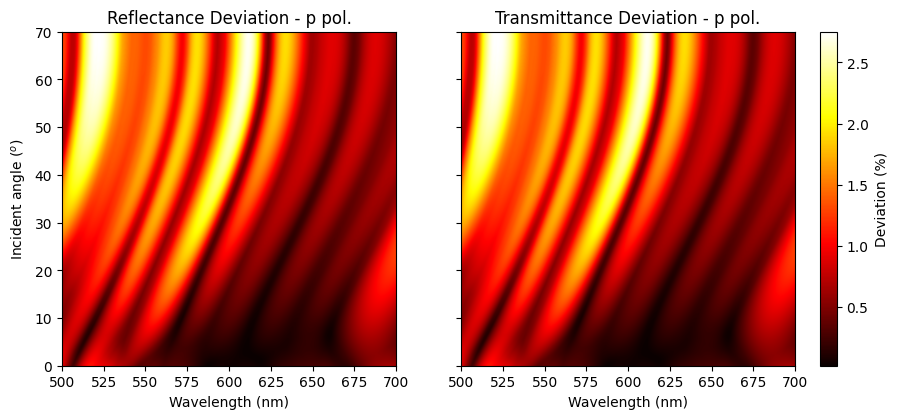

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(R_dev_ppol*100, cmap='hot', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("Reflectance Deviation - p pol.")
    if i ==1:
        im = ax.imshow(T_dev_ppol*100, cmap='hot', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("Transmittance Deviation - p pol.")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Deviation (%)')

plt.savefig("thickness_sensitivity_p_pol.png", dpi=600)
plt.show()